# 01 — Preparação dos dados

Download UCI Beijing Multi-Site (Aotizhongxin), pipeline temporal sem vazamento, PCA 4D e subset compartilhado para SVM/QSVM.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# repo root on path if running without editable install
ROOT = Path.cwd().resolve()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
    sys.path.insert(0, str(ROOT / "src"))

from qml_air_quality.config import load_config, project_root
from qml_air_quality.data import download_dataset, load_station_csv, missing_report
from qml_air_quality.features import (
    add_calendar_features,
    add_future_target,
    add_lag_and_rolling,
    apply_causal_ffill,
    feature_columns,
    impute_with_train_medians,
    make_binary_target,
    save_target_metadata,
)
from qml_air_quality.preprocess import fit_transform_pca, save_pipeline
from qml_air_quality.split import save_sample_indices, stratified_subsample, temporal_split

ROOT = project_root()
cfg = load_config()
SEED = cfg["project"]["random_seed"]
np.random.seed(SEED)
print("Root:", ROOT)
print("Station:", cfg["data"]["station"])

Root: /home/alanveloso/Código/air-quality
Station: Aotizhongxin


## Download e timestamp

In [2]:
csv_path = download_dataset(
    dataset_id=cfg["data"]["dataset_id"],
    station=cfg["data"]["station"],
    raw_dir=ROOT / cfg["data"]["raw_dir"],
)
df = load_station_csv(csv_path)
print(df.shape)
df.head()

(35064, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,timestamp
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


,column,missing,rate
0,PM2.5,925,0.026380
1,PM10,718,0.020477
2,SO2,935,0.026666
3,NO2,1023,0.029175
4,CO,1776,0.050650
5,O3,1719,0.049025
6,TEMP,20,0.000570
7,PRES,20,0.000570
8,DEWP,20,0.000570
9,RAIN,20,0.000570


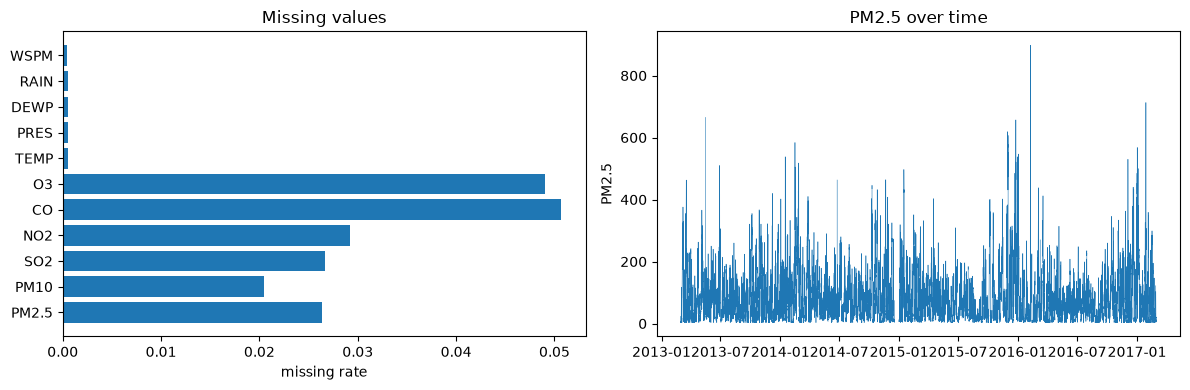

In [3]:
raw_cols = cfg["features"]["raw_columns"]
miss = missing_report(df, raw_cols)
display(miss)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(miss["column"], miss["rate"])
axes[0].set_xlabel("missing rate")
axes[0].set_title("Missing values")
axes[1].plot(df["timestamp"], df["PM2.5"], lw=0.4)
axes[1].set_title("PM2.5 over time")
axes[1].set_ylabel("PM2.5")
fig.tight_layout()
plots = ROOT / cfg["paths"]["plots_dir"]
plots.mkdir(parents=True, exist_ok=True)
fig.savefig(plots / "missing_and_pm25.png", dpi=120)
plt.show()

## Features causais + alvo futuro

In [4]:
ffill_lim = cfg["features"]["ffill_limit_hours"]
df = apply_causal_ffill(df, raw_cols, limit_hours=ffill_lim)
df = add_lag_and_rolling(
    df,
    columns=raw_cols,
    lag_hours=cfg["features"]["lag_hours"],
    rolling_windows=cfg["features"]["rolling_windows"],
)
if cfg["features"]["add_calendar_features"]:
    df = add_calendar_features(df)
df = add_future_target(
    df,
    target_column=cfg["data"]["target_column"],
    horizon_hours=cfg["forecast"]["horizon_hours"],
)
print("rows with future label:", df["future_pm25"].notna().sum())

rows with future label: 34453


## Split temporal → threshold só no treino → imputação residual

In [5]:
train, val, test = temporal_split(
    df,
    train_fraction=cfg["split"]["train_fraction"],
    validation_fraction=cfg["split"]["validation_fraction"],
    test_fraction=cfg["split"]["test_fraction"],
)
print("train/val/test:", len(train), len(val), len(test))
print("periods:")
print("  train", train["timestamp"].min(), "→", train["timestamp"].max())
print("  val  ", val["timestamp"].min(), "→", val["timestamp"].max())
print("  test ", test["timestamp"].min(), "→", test["timestamp"].max())

feat_cols = feature_columns(train)
# exclude columns still mostly empty at this stage carefully — keep raw + engineered
train, val, test = impute_with_train_medians(train, val, test, columns=feat_cols)

train, val, test, tmeta = make_binary_target(
    train, val, test, percentile=cfg["forecast"]["extreme_percentile"]
)
print("threshold:", tmeta)
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(name, "class balance", part["target"].mean())

train/val/test: 20671 6890 6892
periods:
  train 2013-03-01 00:00:00 → 2015-07-29 11:00:00
  val   2015-07-29 12:00:00 → 2016-05-15 09:00:00
  test  2016-05-15 10:00:00 → 2017-02-27 23:00:00
threshold: {'target': 'PM2.5', 'horizon_hours': 24, 'percentile': 0.9, 'threshold': 184.0, 'threshold_source': 'training_partition'}
train class balance 0.10101107832228726
val class balance 0.12612481857764876
test class balance 0.10504933255948927


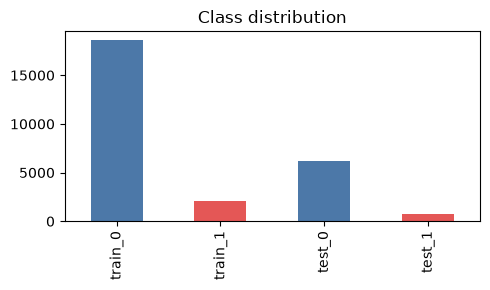

In [6]:
datasets = ROOT / cfg["paths"]["datasets_dir"]
datasets.mkdir(parents=True, exist_ok=True)
save_target_metadata(tmeta, datasets / "target_metadata.json")

fig, ax = plt.subplots(figsize=(5, 3))
counts = pd.Series({
    "train_0": (train["target"] == 0).sum(),
    "train_1": (train["target"] == 1).sum(),
    "test_0": (test["target"] == 0).sum(),
    "test_1": (test["target"] == 1).sum(),
})
counts.plot(kind="bar", ax=ax, color=["#4c78a8", "#e45756", "#4c78a8", "#e45756"])
ax.set_title("Class distribution")
fig.tight_layout()
fig.savefig(plots / "class_distribution.png", dpi=120)
plt.show()

## PCA (fit só no treino) + subset quântico

explained variance ratio: [0.2635687  0.17431233 0.07259021 0.04318452] sum= 0.5536557555965851
shapes (20671, 4) (6890, 4) (6892, 4)


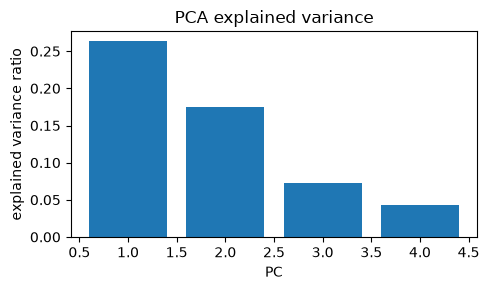

1819

In [7]:
n_pca = cfg["features"]["pca_components"]
X_tr, X_va, X_te, pipe, explained = fit_transform_pca(
    train, val, test, feat_cols, n_components=n_pca
)
print("explained variance ratio:", explained, "sum=", explained.sum())
print("shapes", X_tr.shape, X_va.shape, X_te.shape)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(1, len(explained) + 1), explained)
ax.set_xlabel("PC")
ax.set_ylabel("explained variance ratio")
ax.set_title("PCA explained variance")
fig.tight_layout()
fig.savefig(plots / "pca_explained_variance.png", dpi=120)
plt.show()

models_dir = ROOT / cfg["paths"]["models_dir"]
save_pipeline(pipe, models_dir / "pca_pipeline.joblib")
(datasets / "feature_columns.json").write_text(json.dumps(feat_cols, indent=2), encoding="utf-8")

In [8]:
# attach PCA coords then subsample (same indices for classical & quantum)
train = train.copy()
val = val.copy()
test = test.copy()
for part, X in [(train, X_tr), (val, X_va), (test, X_te)]:
    for i in range(n_pca):
        part[f"pc{i+1}"] = X[:, i]

tr_s, va_s, te_s, idx_table = stratified_subsample(
    train,
    val,
    test,
    train_size=cfg["sampling"]["quantum_train_size"],
    validation_size=cfg["sampling"]["quantum_validation_size"],
    test_size=cfg["sampling"]["quantum_test_size"],
    seed=SEED,
)
save_sample_indices(idx_table, datasets / f"quantum_sample_seed_{SEED}.csv")
print(idx_table["partition"].value_counts())

pc_cols = [f"pc{i+1}" for i in range(n_pca)]
np.save(datasets / "X_train.npy", tr_s[pc_cols].to_numpy())
np.save(datasets / "X_val.npy", va_s[pc_cols].to_numpy())
np.save(datasets / "X_test.npy", te_s[pc_cols].to_numpy())
np.save(datasets / "y_train.npy", tr_s["target"].to_numpy())
np.save(datasets / "y_val.npy", va_s["target"].to_numpy())
np.save(datasets / "y_test.npy", te_s["target"].to_numpy())

meta = {
    "seed": SEED,
    "n_features_before_pca": len(feat_cols),
    "pca_components": n_pca,
    "explained_variance_ratio": explained.tolist(),
    "train_size": len(tr_s),
    "val_size": len(va_s),
    "test_size": len(te_s),
    "threshold": tmeta["threshold"],
}
(datasets / "prepare_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
print("Saved artifacts to", datasets)
meta

partition
train         500
test          200
validation    150
Name: count, dtype: int64
Saved artifacts to /home/alanveloso/Código/air-quality/artifacts/datasets


{'seed': 42,
 'n_features_before_pca': 103,
 'pca_components': 4,
 'explained_variance_ratio': [0.2635686978418024,
  0.17431232879596628,
  0.07259020683637077,
  0.0431845221224456],
 'train_size': 500,
 'val_size': 150,
 'test_size': 200,
 'threshold': 184.0}